# Optimization status

This notebook provides an overview of the optimization history for a given case.
It is designed to help users quickly assess the performance and convergence of
their optimization runs.

Reads the optimisation-history and generates:

- **Case summary**:  
  - steady vs. unsteady, 
  - `end_time`/`timestep`, 
  - the design mapping cascade (with any continuation schedules resolved to
    their current value),
  - a plot of the mapping functions in that cascade that can be drawn as a
    simple curve (e.g. RAMP, SIMP),
- **Objective**:  
  - a plot of the **total objective** together with every objective **scaled
    by its weight** (i.e. its actual contribution to the total),
  - a plot of every objective **unscaled** (raw values),
- **Constraints**:
  - a plot of all **constraints**,
- **Design variables**:
  - a plot of the **design change history**, and
- **KKT residuals**:
  - a plot of the **KKT residuals** (KKTmax, KKTnorm2).

Edit the *Configuration* cell below if your data lives elsewhere.

In [ ]:
# ── Configuration and modules ───────────────────────────────────────────────

%matplotlib inline
import csv
import glob
import json
import os
import re
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Configuration ───────────────────────────────────────────────
WORKDIR = "."  # directory containing the .case file and its result CSV (this notebook's dir)
OUTDIR = "status"  # where PNGs are saved (relative to WORKDIR)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.4,
    "figure.figsize": (8, 4.5),
})


def plot_series(ax, x, y, **kwargs):
    """Plot a line, or a single marker if there's only one data point."""
    if len(x) == 1:
        ax.plot(x, y, marker="o", **kwargs)
    else:
        ax.plot(x, y, **kwargs)

In [3]:
# ── Helper functions ──────────────────────────────────────────────


def find_case_file(workdir: str) -> Optional[str]:
    """Return the .case file in *workdir*, if any."""
    matches = sorted(glob.glob(os.path.join(workdir, "*.case")))
    if not matches:
        return None
    if len(matches) > 1:
        print(
            f"[warn] multiple .case files found in {workdir}; using {os.path.basename(matches[0])}"
        )
    return matches[0]


def _strip_comments(text: str) -> str:
    """Remove // line-comments so JSON5-style .case files parse cleanly."""
    return re.sub(r"//.*?$", "", text, flags=re.MULTILINE)


def load_case_json(path: str) -> dict:
    with open(path, encoding="utf-8") as f:
        raw = f.read()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return json.loads(_strip_comments(raw))


def find_history_csv(workdir: str) -> Optional[str]:
    """Return the optimisation-history CSV in *workdir*, preferring optimization_data.csv."""
    all_csvs = glob.glob(os.path.join(workdir, "*.csv"))
    if not all_csvs:
        return None
    named = [
        p for p in all_csvs if os.path.basename(p) == "optimization_data.csv"
    ]
    if named:
        return named[0]
    prioritised = [
        p for p in all_csvs
        if re.search(r"history|opt|objective|iter", os.path.basename(p), re.I)
    ]
    candidates = prioritised or all_csvs
    candidates.sort(key=os.path.getsize, reverse=True)
    return candidates[0]


def read_history(path: str) -> pd.DataFrame:
    """
    Read a CSV optimisation history, silently skipping repeated header rows
    that appear whenever the run was restarted on the cluster.
    """
    with open(path, encoding="utf-8", errors="replace") as f:
        lines = [
            ln for ln in f.readlines() if ln.strip() and not ln.startswith("#")
        ]
    if not lines:
        return pd.DataFrame()
    try:
        delim = csv.Sniffer().sniff("".join(lines[:20])).delimiter
    except csv.Error:
        delim = ","
    header_line = lines[0].strip()
    columns = [c.strip() for c in header_line.split(delim)]
    rows = []
    for ln in lines[1:]:
        if ln.strip() == header_line:  # repeated header from cluster restart
            continue
        try:
            row = next(csv.reader([ln], delimiter=delim))
        except StopIteration:
            continue
        row = (row + [""] * len(columns))[:len(columns)]
        rows.append(row)
    df = pd.DataFrame(rows, columns=columns)
    df.columns = df.columns.str.strip()
    for col in df.columns:
        s = df[col].astype(str).str.strip()
        df[col] = pd.to_numeric(s.mask(s == ""), errors="coerce")
    return df


# Neko-TOP's CSV column names are NOT derived from the JSON "type" string by
# any general rule (casing is inconsistent between types on purpose). Each
# objective/constraint Fortran type has a hardcoded default log-column name,
# overridable per-instance by an explicit JSON "name" key.
# Sources: sources/problem/objectives/{viscous_dissipation_objective,
# scalar_mixing_objective_function,brinkman_dissipation_objective}.f90,
# sources/problem/constraints/volume_constraint.f90.
TOTAL_OBJECTIVE_COLUMN = "Total objective function"

OBJECTIVE_DEFAULT_NAMES = {
    "viscous_dissipation": "Viscous dissipation",
    "scalar_mixing": "Scalar Mixing",
    "brinkman_dissipation": "Brinkman dissipation",
}

CONSTRAINT_DEFAULT_NAMES = {
    "volume": "Volume constraint",
}


def resolve_objective_and_constraint_columns(case_path: str, columns) -> tuple:
    """
    Determine which CSV *columns* are the objectives/constraints declared in
    the .case JSON at *case_path*, using Neko-TOP's fixed type -> CSV-header
    naming (an entry's own "name" if given, else the hardcoded per-type
    default) rather than guessing from the CSV column names.
    Returns (obj_cols, obj_weight_cols, constr_cols, total_col).
    """
    case_json = load_case_json(case_path)
    optimization = case_json.get("optimization", {})

    def header_for(entry: dict, defaults: dict) -> str:
        return entry.get("name", defaults.get(entry["type"], entry["type"]))

    obj_cols, obj_weight_cols = [], {}
    for entry in optimization.get("objectives", []):
        header = header_for(entry, OBJECTIVE_DEFAULT_NAMES)
        if header not in columns:
            print(f"[warn] objective '{entry['type']}' expected CSV column "
                  f"'{header}' not found")
            continue
        obj_cols.append(header)
        weight_col = f"{header}.weight"
        if weight_col in columns:
            obj_weight_cols[header] = weight_col

    constr_cols = []
    for entry in optimization.get("constraints", []) or []:
        header = header_for(entry, CONSTRAINT_DEFAULT_NAMES)
        if header not in columns:
            print(f"[warn] constraint '{entry['type']}' expected CSV column "
                  f"'{header}' not found")
            continue
        constr_cols.append(header)

    total_col = TOTAL_OBJECTIVE_COLUMN if TOTAL_OBJECTIVE_COLUMN in columns else None

    return obj_cols, obj_weight_cols, constr_cols, total_col


def load_experiment(workdir: str) -> Optional[dict]:
    """
    Load the (single) experiment found in *workdir*.  Returns a dict with
    all data needed for plotting, or None if no CSV can be found.
    """
    case_path = find_case_file(workdir)
    label = (os.path.splitext(os.path.basename(case_path))[0]
             if case_path else os.path.basename(os.path.abspath(workdir)))

    csv_path = find_history_csv(workdir)
    if csv_path is None:
        print(f"[skip] no history CSV found in {workdir}")
        return None

    df = read_history(csv_path)
    if df.empty:
        print(f"[skip] empty CSV: {csv_path}")
        return None

    # Choose iteration-index column
    idx_col = next(
        (c for c in df.columns
         if c.lower() in {"iter", "iteration", "it", "step", "n", "k"}),
        None,
    )
    if idx_col is None:
        df.insert(0, "iter", np.arange(len(df)))
        idx_col = "iter"
    else:
        df = df.sort_values(idx_col).reset_index(drop=True)

    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    skip = {idx_col, "time", "t", "timestamp"}
    metric_cols = [c for c in numeric_cols if c not in skip]

    design_change_col = next(
        (c for c in metric_cols if re.search(r"design.*change", c, re.I)),
        None,
    )
    kkt_cols = [c for c in metric_cols if re.match(r"KKT", c, re.I)]

    if case_path is not None:
        obj_cols, obj_weight_cols, constr_cols, total_col = (
            resolve_objective_and_constraint_columns(case_path, df.columns))
    else:
        print(f"[warn] no .case file found in {workdir}; cannot resolve "
              "objective/constraint columns")
        obj_cols, obj_weight_cols, constr_cols, total_col = [], {}, [], None

    return dict(
        label=label,
        csv_path=csv_path,
        df=df,
        idx_col=idx_col,
        metric_cols=metric_cols,
        total_col=total_col,
        obj_cols=obj_cols,
        obj_weight_cols=obj_weight_cols,
        constr_cols=constr_cols,
        design_change_col=design_change_col,
        kkt_cols=kkt_cols,
    )

In [4]:
# ── Case-file summary helpers ────────────────────────────────────────────────
#
# Reference: Neko-TOP `sources/mapping_functions/*.f90`,
# `sources/continuation/continuation_scheduler.f90`,
# `documentation/pages/user_guide/{simulation_components,mapping_cascade}.md`,
# `documentation/pages/dev_guide/continuation.md`.


# Mapping formulas that reduce to a single-variable curve X_out(X_in) over
# X_in in [0, 1]. PDE_filter is deliberately excluded: it is a spatial
# Helmholtz-type filter solved over the whole mesh, not a per-point function
# of a single input, so it has no such curve.
def _linear_mapping(x, f_min=0.0, f_max=None):
    return f_min + (f_max - f_min) * x


def _ramp_mapping(x, f_min=0.0, f_max=None, q=1.0):
    q_eff = max(float(q), 1e-12)
    return f_min + (f_max - f_min) * x / (1.0 + q_eff * (1.0 - x))


def _borrvall_petersson_mapping(x, f_min=0.0, f_max=None, q=1.0):
    q_eff = max(float(q), 1e-12)
    s = x * (q_eff + 1.0) / (x + q_eff)
    return f_max + (f_min - f_max) * s


def _simp_mapping(x, f_min=0.0, f_max=None, p=1.0):
    return f_min + (f_max - f_min) * x**p


def _heaviside_mapping(x, beta=None, eta=0.5):
    num = np.tanh(beta * eta) + np.tanh(beta * (x - eta))
    den = np.tanh(beta * eta) + np.tanh(beta * (1.0 - eta))
    return num / den


# type string (as used in "optimization.design.mapping[i].type") -> (fn, arg names, defaults)
CURVE_MAPPINGS = {
    "linear": (_linear_mapping, ["f_min", "f_max"], {
        "f_min": 0.0
    }),
    "RAMP": (_ramp_mapping, ["f_min", "f_max", "q"], {
        "f_min": 0.0,
        "q": 1.0
    }),
    "Borrvall_Petersson":
    (_borrvall_petersson_mapping, ["f_min", "f_max", "q"], {
        "f_min": 0.0,
        "q": 1.0
    }),
    "SIMP": (_simp_mapping, ["f_min", "f_max", "p"], {
        "f_min": 0.0,
        "p": 1.0
    }),
    "heaviside_mapping": (_heaviside_mapping, ["beta", "eta"], {
        "eta": 0.5
    }),
    "heaviside_projection": (_heaviside_mapping, ["beta", "eta"], {
        "eta": 0.5
    }),
}


def continuation_value(values: list, iterations_per_value: int,
                       iteration: int):
    """
    Resolve a Neko-TOP continuation array to its value at *iteration* (1-based),
    following the piecewise-constant schedule in continuation_scheduler.f90:
    idx = (iteration - 1) // iterations_per_value, clamped to the last stage.
    """
    idx = max(iteration - 1, 0) // max(iterations_per_value, 1)
    idx = min(idx, len(values) - 1)
    return values[idx]


def summarize_case(case_path: str, current_iteration: int) -> dict:
    """
    Summarize the parts of a .case file relevant to postprocessing: steady vs.
    unsteady, end_time/timestep, the design mapping cascade (resolving any
    continuation-scheduled parameters to their value at *current_iteration*),
    and any continuation schedules found on mapping, objective, or constraint
    parameters.
    """
    case_json = load_case_json(case_path)
    case = case_json.get("case", {})

    simcomps = case.get("simulation_components", [])
    is_steady = any(c.get("type") == "steady" for c in simcomps)
    fluid_freeze = case.get("fluid", {}).get("freeze", False)

    time_cfg = case.get("time", {})
    variable_timestep = time_cfg.get("variable_timestep", False)
    if variable_timestep:
        timestep_info = dict(
            variable=True,
            target_cfl=time_cfg.get("target_cfl"),
            min_timestep=time_cfg.get("min_timestep"),
            max_timestep=time_cfg.get("max_timestep"),
        )
    else:
        timestep_info = dict(variable=False, timestep=time_cfg.get("timestep"))

    optimization = case_json.get("optimization", {})
    design = optimization.get("design", {})
    default_iterations = optimization.get("solver",
                                          {}).get("continuation_iterations", 1)

    def resolve_params(entry: dict) -> tuple:
        """Split a mapping/objective/constraint JSON entry into resolved scalar
        params (continuation arrays evaluated at current_iteration) and a record
        of which params are under continuation."""
        resolved, continuation = {}, {}
        for key, val in entry.items():
            if key == "type" or key.endswith("_iterations"):
                continue
            if isinstance(val, list):
                iterations_per_value = entry.get(f"{key}_iterations",
                                                 default_iterations)
                resolved[key] = continuation_value(val, iterations_per_value,
                                                   current_iteration)
                continuation[key] = dict(
                    values=val, iterations_per_value=iterations_per_value)
            else:
                resolved[key] = val
        return resolved, continuation

    mappings = []
    for entry in design.get("mapping", []):
        mtype = entry.get("type")
        resolved, continuation = resolve_params(entry)
        if mtype in CURVE_MAPPINGS:
            for dk, dv in CURVE_MAPPINGS[mtype][2].items():
                resolved.setdefault(dk, dv)
        mappings.append(
            dict(
                type=mtype,
                params=resolved,
                has_curve=mtype in CURVE_MAPPINGS,
                continuation=continuation,
            ))

    objectives = []
    objective_continuation = {}
    for obj in optimization.get("objectives", []):
        otype = obj.get("type", "?")
        resolved, continuation = resolve_params(obj)
        objectives.append(
            dict(
                type=otype,
                params=resolved,
                continuation=continuation,
            ))
        if "weight" in continuation:
            objective_continuation[otype] = dict(
                values=continuation["weight"]["values"],
                iterations_per_value=continuation["weight"]
                ["iterations_per_value"],
                current=continuation_value(
                    continuation["weight"]["values"],
                    continuation["weight"]["iterations_per_value"],
                    current_iteration,
                ),
            )

    constraints = []
    for con in optimization.get("constraints", []):
        ctype = con.get("type", "?")
        resolved, continuation = resolve_params(con)
        constraints.append(
            dict(
                type=ctype,
                params=resolved,
                continuation=continuation,
            ))

    return dict(
        label=os.path.splitext(os.path.basename(case_path))[0],
        is_steady=is_steady,
        fluid_freeze=fluid_freeze,
        end_time=time_cfg.get("end_time"),
        timestep_info=timestep_info,
        mappings=mappings,
        objectives=objectives,
        constraints=constraints,
        objective_continuation=objective_continuation,
    )

In [5]:
# ── Load the experiment ──────────────────────────────────────────────
exp = load_experiment(WORKDIR)
if exp is None:
    print(f"No experiment loaded – check WORKDIR ('{WORKDIR}').")
else:
    print(
        f"Loaded {exp['label']} ({exp['csv_path']}) → {len(exp['df'])} iterations"
    )

[warn] multiple .case files found in .; using steady_200.case
[skip] no history CSV found in .
No experiment loaded – check WORKDIR ('.').


## Case file summary

In [6]:
# ── Case summary ───────────────────────────────────────────────────────────
case_summary = None

case_path = find_case_file(WORKDIR)
if case_path is None:
    print("No .case file found – skipping case summary.")
else:
    # Print the current iteration
    print(f"Case file: {os.path.basename(case_path)}")

    if exp is not None:
        current_iteration = int(exp["df"][exp["idx_col"]].iloc[-1]) + 1
        print(f"  - Current iteration: {current_iteration}")
    else:
        current_iteration = 0
    case_summary = summarize_case(case_path, current_iteration)

    # Print information related to the physics:
    regime = "steady" if case_summary["is_steady"] else "unsteady"
    print(f"  - Regime:    {regime}")

    ti = case_summary["timestep_info"]
    print(f"  - end_time:  {case_summary['end_time']}")
    if ti["variable"]:
        print(f"  - timestep:  variable (target_cfl={ti['target_cfl']}, "
              f"min={ti['min_timestep']}, max={ti['max_timestep']})")
    else:
        print(f"  - timestep:  {ti['timestep']}")

    print("\nObjectives in case file:")
    if case_summary["objectives"]:
        for obj in case_summary["objectives"]:
            params_str = ", ".join(f"{k}={v}"
                                   for k, v in obj["params"].items())
            print(f"  - {obj['type']}({params_str})")
            for key, cont in obj["continuation"].items():
                print(
                    f"       continuation on '{key}': values={cont['values']}, "
                    f"iterations_per_value={cont['iterations_per_value']}")
    else:
        print("  (none)")

    if case_summary["constraints"]:
        print("\nConstraints in case file:")
        for con in case_summary["constraints"]:
            params_str = ", ".join(f"{k}={v}"
                                   for k, v in con["params"].items())
            print(f"  - {con['type']}({params_str})")
            for key, cont in con["continuation"].items():
                print(
                    f"       continuation on '{key}': values={cont['values']}, "
                    f"iterations_per_value={cont['iterations_per_value']}")

    print("\nMapping cascade (in execution order):")
    for i, m in enumerate(case_summary["mappings"]):
        params_str = ", ".join(f"{k}={v}" for k, v in m["params"].items())
        print(f"  {i + 1}. {m['type']}({params_str})")
        for key, cont in m["continuation"].items():
            print(f"       continuation on '{key}': values={cont['values']}, "
                  f"iterations_per_value={cont['iterations_per_value']}")
    if not case_summary["mappings"]:
        print("  (none)")

    if case_summary["objective_continuation"]:
        print("\nObjective weight continuation:")
        for name, cont in case_summary["objective_continuation"].items():
            print(f"  {name}: values={cont['values']}, "
                  f"iterations_per_value={cont['iterations_per_value']}, "
                  f"current={cont['current']:.6g}")

[warn] multiple .case files found in .; using steady_200.case
Case file: steady_200.case
  - Regime:    steady
  - end_time:  12.0
  - timestep:  0.0004

Objectives in case file:
  - scalar_mixing(mask_name=objective_domain, phi_ref=0.5, weight=10.8336275609)
  - viscous_dissipation(weight=1.19703784706)
  - brinkman_dissipation(weight=45.10107562188)

Mapping cascade (in execution order):
  1. PDE_filter(r=0.015625, tol=1e-15)
  2. RAMP(f_max=1000.0, q=10.0, f_min=0.0)


## Mapping functions

Overview of the mapping functions applied in this case.

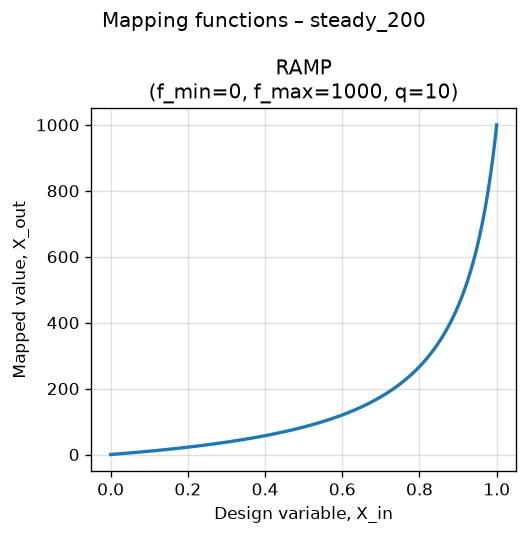

In [7]:
# ── Mapping functions ─────────────────────────────────────────────────────────
os.makedirs(OUTDIR, exist_ok=True)

if case_summary is not None:
    curve_maps = [m for m in case_summary["mappings"] if m["has_curve"]]
    if not curve_maps:
        print("No mapping functions to plot in the design cascade.")
    else:
        x = np.linspace(0.0, 1.0, 400)
        n = len(curve_maps)
        fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5), squeeze=False)
        for ax, m in zip(axes[0], curve_maps):
            fn, arg_names, _ = CURVE_MAPPINGS[m["type"]]
            kwargs = {k: m["params"][k] for k in arg_names if k in m["params"]}
            y = fn(x, **kwargs)
            params_str = ", ".join(f"{k}={v:g}" for k, v in kwargs.items())
            ax.plot(x, y, linewidth=2)
            ax.set_xlabel("Design variable, X_in")
            ax.set_ylabel("Mapped value, X_out")
            ax.set_title(f"{m['type']}\n({params_str})")

        fig.suptitle(f"Mapping functions – {case_summary['label']}")
        fig.tight_layout()
        fig.savefig(os.path.join(OUTDIR, "mapping_functions.png"))
        plt.show()

## Objectives and constraints

In [8]:
# ── Objectives: total + weight-scaled components ─────────────────────────────
os.makedirs(OUTDIR, exist_ok=True)

if exp is not None:
    df, idx = exp["df"], exp["idx_col"]
    obj_cols, weight_cols = exp["obj_cols"], exp["obj_weight_cols"]

    fig, ax = plt.subplots()
    if exp["total_col"]:
        plot_series(ax, df[idx], df[exp["total_col"]], label="Total objective")
    for col in obj_cols:
        scaled = df[col] * df[weight_cols[col]]
        plot_series(ax, df[idx], scaled, label=f"{col} (scaled)")

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Objective value")
    ax.set_title(f"Objectives, scaled by weight – {exp['label']}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, "obj_scaled.png"))
    plt.show()

In [9]:
# ── Objectives: unscaled components ───────────────────────────────────────────
if exp is not None:
    df, idx = exp["df"], exp["idx_col"]
    obj_cols = exp["obj_cols"]
    if not obj_cols:
        print("No objective columns detected.")
    else:
        fig, ax = plt.subplots()
        for col in obj_cols:
            plot_series(ax, df[idx], df[col], label=col)

        ax.set_xlabel("Iteration")
        ax.set_ylabel("Objective value")
        ax.set_title(f"Objectives, unscaled – {exp['label']}")
        ax.legend()
        fig.tight_layout()
        fig.savefig(os.path.join(OUTDIR, "obj_unscaled.png"))
        plt.show()

In [10]:
# ── Constraints (all on one plot) ─────────────────────────────────────────────
if exp is not None:
    df, idx = exp["df"], exp["idx_col"]
    constr_cols = exp["constr_cols"]
    if constr_cols:
        fig, ax = plt.subplots()
        for col in constr_cols:
            plot_series(ax, df[idx], df[col], label=col)

        ax.set_xlabel("Iteration")
        ax.set_ylabel("Constraint value")
        ax.set_title(f"Constraints – {exp['label']}")
        ax.legend()
        fig.tight_layout()
        fig.savefig(os.path.join(OUTDIR, "constraints.png"))
        plt.show()

## Design change history

In [11]:
# ── Design change history ─────────────────────────────────────────────────────
if exp is not None:
    df, idx = exp["df"], exp["idx_col"]
    dc_col = exp["design_change_col"]
    if dc_col is None:
        print("No design-change column detected.")
    elif len(df) < 1:
        print("Design-change history is empty.")
    else:
        fig, ax = plt.subplots()
        plot_series(ax, df[idx][1:], df[dc_col][1:], label=dc_col)

        ax.set_xlabel("Iteration")
        ax.set_ylabel(dc_col)
        ax.set_title(f"Design change history – {exp['label']}")
        ax.legend()
        fig.tight_layout()
        fig.savefig(os.path.join(OUTDIR, "design_change.png"))
        plt.show()

## KKT residuals

In [12]:
# ── KKT residuals (KKTmax, KKTnorm2) ──────────────────────────────────────────
if exp is not None:
    df, idx = exp["df"], exp["idx_col"]
    kkt_cols = exp["kkt_cols"]
    if not kkt_cols:
        print("No KKT columns detected.")
    elif len(df) < 1:
        print("KKT history is empty.")
    else:
        fig, ax = plt.subplots()
        for col in kkt_cols:
            plot_series(ax, df[idx][1:], df[col][1:], label=col)

        ax.set_xlabel("Iteration")
        ax.set_ylabel("KKT residual")
        ax.set_title(f"KKT residuals – {exp['label']}")
        ax.legend()
        fig.tight_layout()
        fig.savefig(os.path.join(OUTDIR, "kkt.png"))
        plt.show()